# 🎮 Análisis y Predicción de Géneros en Videojuegos de PlayStation

## Entrega Final - Ciencia de Datos

En este trabajo se analiza un dataset de videojuegos de PlayStation con el objetivo de encontrar patrones en géneros, desarrolladores y empresas editoras.

Además del análisis exploratorio, se plantea un problema de Machine Learning: predecir si un videojuego pertenece al género **Action role-playing** a partir de variables como el desarrollador y la empresa editora.

## 1. Abstract y audiencia

La industria de los videojuegos tiene una gran variedad de géneros y empresas participantes. Analizar estos datos permite entender mejor cómo se distribuye la oferta dentro del catálogo de PlayStation.

Este proyecto puede ser útil para estudiantes, analistas de mercado, desarrolladores o empresas editoras que quieran identificar tendencias dentro de la industria.

A partir del análisis exploratorio, se busca responder si existen patrones que permitan predecir el género de un videojuego usando información disponible en el dataset.

## 2. Problema a resolver

Primero se realiza un análisis exploratorio para conocer el dataset. Luego, se plantea un problema de **clasificación binaria**.

La variable objetivo será:

- `1`: el videojuego pertenece al género **Action role-playing**
- `0`: el videojuego pertenece a otro género

La idea es evaluar si variables como `developer` y `publisher` permiten predecir este género.

## 3. Obtención de datos desde API

En esta sección se consumen los datos desde una API pública de SampleAPIs. Luego se guardan en un archivo CSV local dentro de la carpeta `data`, para poder reutilizarlos durante el análisis y el entrenamiento de modelos.

Este bloque retoma la lógica utilizada en la primera entrega.

In [ ]:
import requests
import pandas as pd
import os

url = "https://api.sampleapis.com/playstation/games"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data)

    if not os.path.exists('data'):
        os.makedirs('data')

    df.to_csv("data/videojuegos_playstation.csv", index=False)

    print("Datos cargados correctamente")
    print(df.head())
else:
    print("Error:", response.status_code)

## 4. Carga de datos

Se carga el archivo CSV generado a partir de la API pública de videojuegos de PlayStation.

In [ ]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

df = pd.read_csv("data/videojuegos_playstation.csv")
df.head()

,id,name,genre,developers,publishers,releaseDates
0,1,#killallzombies,['Shooter'],['Beatshapers'],['Beatshapers'],"{'Japan': 'Unreleased', 'NorthAmerica': 'Nov 1..."
1,2,10 Second Ninja X,['Platform'],['Four Circle Interactive'],['Curve Digital'],"{'Japan': 'Unreleased', 'NorthAmerica': 'Jul 1..."
2,3,100ft Robot Golf,['Sports'],['No Goblin'],['No Goblin'],"{'Japan': 'Unreleased', 'NorthAmerica': 'Oct 1..."
3,4,101 Ways to Die,['puzzle'],['Four Door Lemon'],['Vision Games'],"{'Japan': 'Unreleased', 'NorthAmerica': 'Mar 2..."
4,5,11-11: Memories Retold,[],"['Aardman', 'DigixArt']",['Bandai Namco Entertainment'],"{'Japan': 'Nov 9, 2018', 'NorthAmerica': 'Nov ..."


In [2]:
# Reviso tamaño del dataset y columnas disponibles
print("Filas y columnas:", df.shape)
df.columns

Filas y columnas: (1151, 6)


Index(['id', 'name', 'genre', 'developers', 'publishers', 'releaseDates'], dtype='object')

## 5. Limpieza y preparación inicial

En el dataset, algunas columnas vienen guardadas como texto con formato de lista. Por ejemplo: `['Shooter']`.

Para poder trabajar mejor con los datos, convierto esos valores a listas reales y luego me quedo con el primer valor de cada lista. Esto simplifica el análisis y hace que el modelo pueda usar las variables.

In [3]:
# Función simple para convertir texto con forma de lista en una lista real
def convertir_lista(valor):
    try:
        resultado = ast.literal_eval(valor)
        if isinstance(resultado, list):
            return resultado
        else:
            return []
    except:
        return []

# Aplico la conversión a las columnas principales
df['genre_list'] = df['genre'].apply(convertir_lista)
df['developers_list'] = df['developers'].apply(convertir_lista)
df['publishers_list'] = df['publishers'].apply(convertir_lista)

# Me quedo con filas que tienen género cargado
df = df[df['genre_list'].apply(lambda x: len(x) > 0)]

# Creo columnas limpias
df['genre_clean'] = df['genre_list'].apply(lambda x: x[0])
df['developer'] = df['developers_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
df['publisher'] = df['publishers_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

df = df[['name', 'genre_clean', 'developer', 'publisher']]
df.head()

,name,genre_clean,developer,publisher
0,#killallzombies,Shooter,Beatshapers,Beatshapers
1,10 Second Ninja X,Platform,Four Circle Interactive,Curve Digital
2,100ft Robot Golf,Sports,No Goblin,No Goblin
3,101 Ways to Die,puzzle,Four Door Lemon,Vision Games
11,The 25th Ward: The Silver Case,Visual novel,Grasshopper Manufacture,NIS America


In [4]:
print("Filas después de limpiar:", len(df))
df.isnull().sum()

Filas después de limpiar: 148


name           0
genre_clean    0
developer      0
publisher      0
dtype: int64

## 6. Breve análisis exploratorio

Antes de entrenar modelos, observo cuáles son los géneros más frecuentes. Esto ayuda a entender la distribución de los datos y también a detectar posibles desbalances.

In [5]:
df['genre_clean'].value_counts().head(10)

genre_clean
Hidden object            7
Action role-playing      7
Shoot 'em up             7
Tactical role-playing    6
Action-adventure         6
Role-playing             6
Adventure                5
Beat 'em up              5
Action                   4
Metroidvania             4
Name: count, dtype: int64

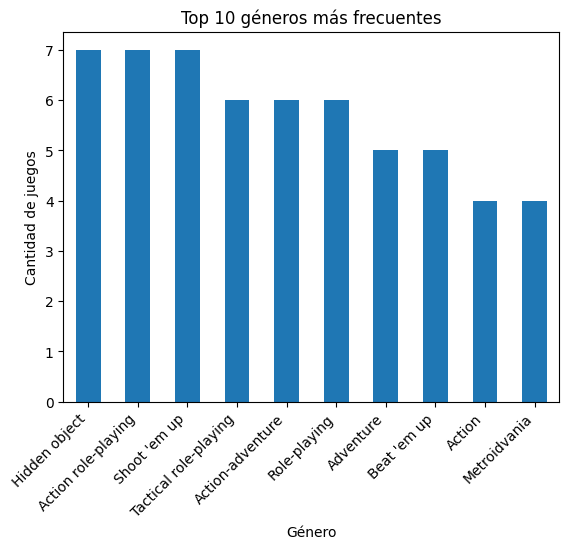

In [6]:
df['genre_clean'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 géneros más frecuentes")
plt.xlabel("Género")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=45, ha='right')
plt.show()

A partir de este análisis se observa que algunos géneros aparecen con más frecuencia que otros. Esto es importante porque el modelo puede verse afectado si una clase tiene muchos más casos que otra.

## 7. Creación de la variable objetivo

Se crea una variable llamada `is_action_rpg`, que indica si un juego pertenece al género **Action role-playing**.

Para evitar problemas con mayúsculas y minúsculas, convierto el texto a minúsculas antes de comparar.

In [7]:
df['is_action_rpg'] = df['genre_clean'].apply(
    lambda x: 1 if 'action role-playing' in str(x).lower() else 0
)

df[['name', 'genre_clean', 'is_action_rpg']].head()

,name,genre_clean,is_action_rpg
0,#killallzombies,Shooter,0
1,10 Second Ninja X,Platform,0
2,100ft Robot Golf,Sports,0
3,101 Ways to Die,puzzle,0
11,The 25th Ward: The Silver Case,Visual novel,0


In [8]:
# Reviso el balance de clases
df['is_action_rpg'].value_counts()

is_action_rpg
0    141
1      7
Name: count, dtype: int64

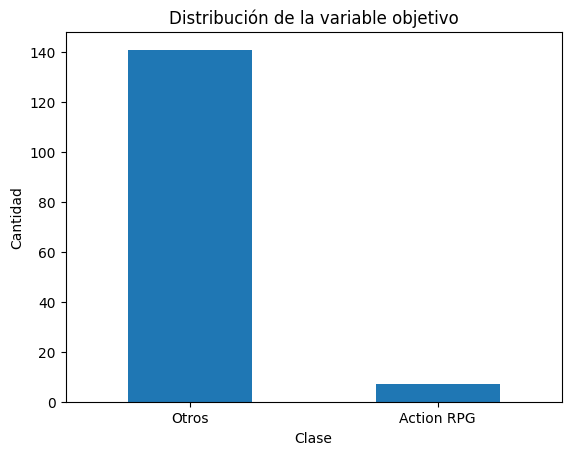

In [9]:
df['is_action_rpg'].value_counts().plot(kind='bar')
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks([0, 1], ['Otros', 'Action RPG'], rotation=0)
plt.show()

Se puede ver que la clase Action RPG tiene menos casos que la clase "Otros". Esto es una limitación del dataset, pero igual permite realizar una primera aproximación al problema de clasificación.

## 8. Ingeniería de atributos

Los modelos de Machine Learning no pueden trabajar directamente con texto. Por eso convierto las variables categóricas (`developer` y `publisher`) a variables numéricas usando encoding.

También agrupo valores poco frecuentes en la categoría `Other` para reducir la cantidad de columnas generadas.

In [10]:
# Agrupo developers y publishers poco frecuentes
top_developers = df['developer'].value_counts().head(20).index
top_publishers = df['publisher'].value_counts().head(10).index

df['developer_group'] = df['developer'].apply(lambda x: x if x in top_developers else 'Other')
df['publisher_group'] = df['publisher'].apply(lambda x: x if x in top_publishers else 'Other')

# Encoding de variables categóricas
X = pd.get_dummies(df[['developer_group', 'publisher_group']])
y = df['is_action_rpg']

X.head()

,developer_group_Ankake Supa,developer_group_Artifex Mundi,developer_group_Auroch Digital,developer_group_Beatshapers,developer_group_Bloober Team,developer_group_Cave,developer_group_Four Circle Interactive,developer_group_Four Door Lemon,developer_group_Giant Squid,developer_group_Grasshopper Manufacture,...,publisher_group_Artifex Mundi,publisher_group_Curve Digital,publisher_group_Devolver Digital,publisher_group_Mediascape,publisher_group_Other,publisher_group_Sony Computer Entertainment,publisher_group_Sony Interactive Entertainment,publisher_group_Spike Chunsoft,publisher_group_Square Enix,publisher_group_Versus Evil
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
11,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False


## 9. Separación en entrenamiento y testeo

Se separan los datos en entrenamiento y testeo para evaluar el rendimiento del modelo con datos que no vio durante el entrenamiento.

Uso `stratify=y` para mantener una proporción similar de clases en ambos conjuntos.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (118, 32)
Test: (30, 32)


## 10. Modelo 1: Regresión Logística

Primero se entrena una Regresión Logística, que es un modelo simple y sirve como punto de comparación.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=2000, class_weight='balanced')
log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

print("Accuracy Logistic Regression:", accuracy_score(y_test, pred_log))
print(classification_report(y_test, pred_log, zero_division=0))

Accuracy Logistic Regression: 0.9666666666666667
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.48      0.50      0.49        30
weighted avg       0.93      0.97      0.95        30



## 11. Modelo 2: Random Forest

Luego se entrena un modelo Random Forest. Este modelo suele funcionar mejor cuando hay relaciones más complejas entre las variables.

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf, zero_division=0))

Accuracy Random Forest: 0.9666666666666667
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.48      0.50      0.49        30
weighted avg       0.93      0.97      0.95        30



## 12. Validación cruzada

La validación cruzada permite evaluar si el modelo mantiene un rendimiento parecido usando distintas divisiones de los datos.

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)

print("Resultados de cada fold:", scores)
print("Accuracy promedio (CV):", scores.mean())

Resultados de cada fold: [0.46666667 0.33333333 0.93333333 0.96551724 0.96551724]
Accuracy promedio (CV): 0.7328735632183909


## 13. Optimización de hiperparámetros

Para mejorar el modelo Random Forest, se prueban distintas combinaciones de parámetros usando GridSearchCV.

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=3
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'max_depth': 5, 'n_estimators': 50}


In [16]:
best_model = grid.best_estimator_
pred_best = best_model.predict(X_test)

print("Accuracy modelo optimizado:", accuracy_score(y_test, pred_best))
print(classification_report(y_test, pred_best, zero_division=0))

Accuracy modelo optimizado: 0.9666666666666667
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.48      0.50      0.49        30
weighted avg       0.93      0.97      0.95        30



## 14. Selección del modelo

Se compararon dos modelos: Regresión Logística y Random Forest.

Random Forest resulta más adecuado para este caso porque puede capturar relaciones más complejas entre `developer`, `publisher` y el género del videojuego.

De todos modos, el dataset tiene limitaciones importantes, principalmente el desbalance entre clases y la poca cantidad de variables disponibles.

## 15. Conclusiones

El análisis permitió observar que el catálogo de videojuegos de PlayStation presenta una gran variedad de géneros, pero algunos aparecen con mayor frecuencia que otros.

A partir del análisis exploratorio surgió la pregunta de si era posible predecir el género de un videojuego usando información como el desarrollador y la empresa editora. Para responderla, se creó un problema de clasificación binaria orientado a detectar juegos del género Action RPG.

Los resultados muestran que es posible realizar una primera predicción, aunque el modelo no es perfecto. Esto se debe principalmente a que el dataset tiene pocas variables explicativas y la clase Action RPG aparece en pocos casos.

Como mejora futura, se podrían incorporar nuevas variables como año de lanzamiento, ventas, rating o plataformas, para obtener modelos con mayor capacidad predictiva.

## 16. Requisitos para ejecutar el notebook

Para correr este notebook se necesitan las siguientes librerías:

- pandas
- matplotlib
- scikit-learn
- requests

Si alguna no está instalada, se puede instalar con:

```bash
pip install pandas matplotlib scikit-learn requests
```